<a href="https://colab.research.google.com/github/sanjanapatilvv5/NNDL-Lab/blob/main/NNDL_EXP_6_8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#EXP-6-------

!pip install tensorflow


import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Embedding
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences

max_features = 10000
maxlen = 100

(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=max_features)


x_train = pad_sequences(x_train, maxlen=maxlen)
x_test = pad_sequences(x_test, maxlen=maxlen)


model = Sequential()
model.add(Embedding(max_features, 32, input_length=maxlen))
model.add(SimpleRNN(32))
model.add(Dense(1, activation='sigmoid'))


model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])


model.fit(x_train, y_train, epochs=5, batch_size=64, validation_split=0.2)


loss, accuracy = model.evaluate(x_test, y_test)


print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


313/313 ━━━━━━━━━━━━━━━━━━━━ 13s 35ms/step - accuracy: 0.5804 - loss: 0.6661 - val_accuracy: 0.6544 - val_loss: 0.6108
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 27ms/step - accuracy: 0.8174 - loss: 0.4083 - val_accuracy: 0.8076 - val_loss: 0.4355
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 31ms/step - accuracy: 0.9213 - loss: 0.2068 - val_accuracy: 0.8202 - val_loss: 0.4551
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 31ms/step - accuracy: 0.9759 - loss: 0.0768 - val_accuracy: 0.7572 - val_loss: 0.6277
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 28ms/step - accuracy: 0.9933 - loss: 0.0280 - val_accuracy: 0.8004 - val_loss: 0.6541
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.7968 - loss: 0.6680
Test Loss: 0.6680359244346619
Test Accuracy: 0.7967600226402283


In [2]:
#EXP-7-------
!pip install tensorflow scikit-learn

import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, RepeatVector, TimeDistributed, Dense
from sklearn.preprocessing import MinMaxScaler

np.random.seed(42)

# Generate normal data (100 samples, 10 timesteps, 1 feature)
normal_data = np.random.normal(loc=0, scale=1, size=(100, 10, 1))

# Scale data
scaler = MinMaxScaler()
normal_data = scaler.fit_transform(normal_data.reshape(-1, 1)).reshape(100, 10, 1)

# Model
inputs = Input(shape=(10, 1))
encoded = LSTM(32, activation='relu')(inputs)
decoded = RepeatVector(10)(encoded)
decoded = LSTM(32, activation='relu', return_sequences=True)(decoded)
decoded = TimeDistributed(Dense(1))(decoded)

autoencoder = Model(inputs, decoded)

# Compile
autoencoder.compile(optimizer='adam', loss='mse')

# Train
autoencoder.fit(normal_data, normal_data,
                epochs=20,
                batch_size=32,
                validation_split=0.2)

# Reconstruction
reconstructed = autoencoder.predict(normal_data)

# Compute reconstruction error (MSE)
mse = np.mean(np.power(normal_data - reconstructed, 2), axis=(1,2))

# Threshold
threshold = np.mean(mse) + 2*np.std(mse)
print("Threshold:", threshold)

# Detect anomalies
anomalies = mse > threshold
print("Number of anomalies detected:", np.sum(anomalies))

Epoch 1/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 325ms/step - loss: 0.2221 - val_loss: 0.2278
Epoch 2/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - loss: 0.2089 - val_loss: 0.2144
Epoch 3/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 0.1963 - val_loss: 0.2006
Epoch 4/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 0.1836 - val_loss: 0.1863
Epoch 5/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 0.1700 - val_loss: 0.1705
Epoch 6/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 0.1549 - val_loss: 0.1527
Epoch 7/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 0.1381 - val_loss: 0.1327
Epoch 8/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 0.1191 - val_loss: 0.1102
Epoch 9/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 0.0978 - val_loss: 0.0855
Epoch 10/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - loss: 0.0757 - val_loss: 0.0615
Epoch 11/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 0.0558 - val_loss: 0.0470
Epoch 12/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 0.0484 - val_loss: 0.0527


Epoch 1/5
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 348ms/step - bbox_output_loss: 0.1865 - class_output_accuracy: 0.4800 - class_output_loss: 3.7176 - loss: 4.2766
Epoch 2/5
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 344ms/step - bbox_output_loss: 0.0914 - class_output_accuracy: 0.4800 - class_output_loss: 0.7414 - loss: 0.8457
Epoch 3/5
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 494ms/step - bbox_output_loss: 0.0830 - class_output_accuracy: 0.5400 - class_output_loss: 0.6913 - loss: 0.7752
Epoch 4/5
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 413ms/step - bbox_output_loss: 0.0769 - class_output_accuracy: 0.5400 - class_output_loss: 0.6935 - loss: 0.7696
Epoch 5/5
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 343ms/step - bbox_output_loss: 0.0757 - class_output_accuracy: 0.6100 - class_output_loss: 0.6859 - loss: 0.7642
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step
Car Probability: [[0.5022338]]
Predicted Bounding Box: [[0.47289148 0.51073384 0.49793282 0.49477234]]


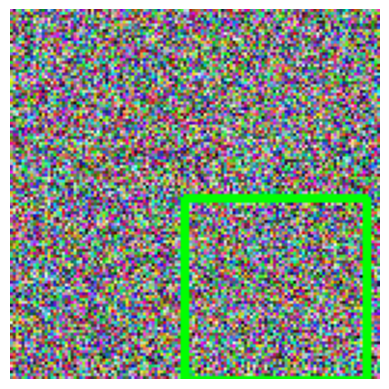

In [3]:
#EXP------8
# Install libraries
!pip install tensorflow opencv-python matplotlib

# Imports
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models

# Dummy dataset (images + labels)
X = np.random.rand(100, 128, 128, 3)

# Class label (car present or not: 0/1)
y_class = np.random.randint(0, 2, (100, 1))

# Bounding box: [x, y, width, height]
y_bbox = np.random.rand(100, 4)

# Input layer
input_layer = layers.Input(shape=(128, 128, 3))

# CNN layers
x = layers.Conv2D(32, (3, 3), activation="relu")(input_layer)
x = layers.MaxPooling2D((2, 2))(x)

x = layers.Conv2D(64, (3, 3), activation="relu")(x)
x = layers.MaxPooling2D((2, 2))(x)

x = layers.Flatten()(x)
x = layers.Dense(128, activation="relu")(x)

# Outputs
class_output = layers.Dense(1, activation="sigmoid", name="class_output")(x)
bbox_output = layers.Dense(4, activation="sigmoid", name="bbox_output")(x)

# Model
model = models.Model(inputs=input_layer, outputs=[class_output, bbox_output])

# Compile
model.compile(
    optimizer="adam",
    loss={
        "class_output": "binary_crossentropy",
        "bbox_output": "mse"
    },
    metrics={
        "class_output": "accuracy"
    }
)

# Train
model.fit(
    X,
    {"class_output": y_class, "bbox_output": y_bbox},
    epochs=5,
    batch_size=16
)

# Test prediction
test_img = np.random.rand(1, 128, 128, 3)
pred_class, pred_bbox = model.predict(test_img)

print("Car Probability:", pred_class)
print("Predicted Bounding Box:", pred_bbox)

# Draw bounding box
img = (test_img[0] * 255).astype(np.uint8)

h, w, _ = img.shape
x1 = int(pred_bbox[0][0] * w)
y1 = int(pred_bbox[0][1] * h)
bw = int(pred_bbox[0][2] * w)
bh = int(pred_bbox[0][3] * h)

cv2.rectangle(img, (x1, y1), (x1 + bw, y1 + bh), (0, 255, 0), 2)

plt.imshow(img)
plt.axis("off")
plt.show()